# Phase 2 — Logistic Regression

**Sentiment140 — Twitter sentiment classification.** This notebook is self-contained: it rebuilds the 1M balanced sample (500K per class) from the raw CSV, applies the canonical preprocessing pipeline, fits a baseline TF-IDF vectorizer (5,000 features, unigrams + bigrams), and produces an 80/20 stratified train/test split before training the model.

**Participants:** Noam Kadosh · Roy Boker · Gal Tayeb · Noam Dahan


---
## 1. Data preparation

Reproduces the Phase 1 pipeline end-to-end so this notebook stands on its own:

1. Load the full 1.6M-tweet CSV.
2. Draw the same balanced 1M sample (500K per class, `random_state=42`).
3. Apply `preprocess_tweet` (lowercase → strip URLs/@/RT/HTML → drop `#` → alpha-only → tokenize → stopwords → lemmatize).
4. Fit `TfidfVectorizer(max_features=5000, ngram_range=(1, 2))`.
5. Remap labels `{0, 4} → {0, 1}` and run an 80/20 stratified split.


In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pandas', 'matplotlib', 'seaborn', 'nltk', 'scikit-learn'])
print('Dependencies ready.')


Dependencies ready.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
PALETTE = ['#e74c3c', '#2ecc71']  # neg, pos — matches Phase 1
print('Imports ready.')


Imports ready.


In [3]:
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df_full = pd.read_csv('../data-sets/training.1600000.processed.noemoticon.csv',
                      encoding='latin-1', header=None, names=columns)
print(f'Full dataset shape: {df_full.shape}')
df_full['sentiment'].value_counts().sort_index()


Full dataset shape: (1600000, 6)


sentiment
0    800000
4    800000
Name: count, dtype: int64

In [4]:
SAMPLE_SIZE = 500000  # per class (matches Phase 1)
df = pd.concat([
    df_full[df_full['sentiment'] == 0].sample(SAMPLE_SIZE, random_state=42),
    df_full[df_full['sentiment'] == 4].sample(SAMPLE_SIZE, random_state=42)
]).reset_index(drop=True)

df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})
print(f'Balanced sample size: {len(df):,}')
print(df['sentiment_label'].value_counts())


Balanced sample size: 1,000,000
sentiment_label
Negative    500000
Positive    500000
Name: count, dtype: int64


In [5]:
def preprocess_tweet(text):
    """Canonical preprocessing pipeline (copied verbatim from Phase 1)."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)         # URLs
    text = re.sub(r'@\w+', '', text)                    # mentions
    text = re.sub(r'^rt\s+', '', text)                  # RT prefix
    text = re.sub(r'&\w+;', '', text)                   # HTML entities
    text = text.replace('#', '')                         # keep hashtag word
    text = re.sub(r'[^a-z\s]', '', text)                # alpha only
    text = re.sub(r'\s+', ' ', text).strip()            # collapse whitespace
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 1]
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# quick sanity check
preprocess_tweet('@user check out https://example.com #happy! It is great :)')


'check happy great'

In [6]:
df['text_clean'] = df['text'].apply(preprocess_tweet)
empty_after_clean = (df['text_clean'].str.strip() == '').sum()
print(f'Empty tweets after cleaning: {empty_after_clean}')
df[['text', 'text_clean']].head(3)


Empty tweets after cleaning: 5060


,text,text_clean
0,@xnausikaax oh no! where did u order from? tha...,oh order thats horrible
1,A great hard training weekend is over. a coup...,great hard training weekend couple day rest le...
2,"Right, off to work Only 5 hours to go until I...",right work hour go im free xd


In [7]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['text_clean'])
print(f'TF-IDF matrix: {X_tfidf.shape}, sparsity '
      f'{1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4%}')


TF-IDF matrix: (1000000, 5000), sparsity 99.8714%


In [8]:
# PDF requires {0, 4} -> {0, 1} remap before modeling
y = df['sentiment'].map({0: 0, 4: 1}).values
print(f'Label distribution: {pd.Series(y).value_counts().to_dict()}')


Label distribution: {0: 500000, 1: 500000}


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=42)
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')


Train: 800,000 samples
Test:  200,000 samples


---
## 2. Model — Logistic Regression

Logistic Regression is a strong, **interpretable** linear model for text classification: each TF-IDF feature gets a learned coefficient that we can read off directly to see which words drive each class. It is robust on sparse features and provides a principled probabilistic output.


In [10]:
def report_metrics(model_name, y_true, y_pred):
    """Print the four required metrics + classification report."""
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
    }
    print(f"=== {model_name} ===")
    for k in ['accuracy', 'precision', 'recall', 'f1']:
        print(f"  {k:9s} {metrics[k]:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                target_names=['Negative', 'Positive']))
    return metrics


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=1.0, max_iter=1000)
t0 = time.time()
model.fit(X_train, y_train)
train_seconds = time.time() - t0
print(f'Training time: {train_seconds:.2f} s')


Training time: 0.69 s


In [12]:
y_pred = model.predict(X_test)
metrics = report_metrics('Logistic Regression', y_test, y_pred)
metrics['train_seconds'] = train_seconds
metrics


=== Logistic Regression ===
  accuracy  0.7748
  precision 0.7638
  recall    0.7956
  f1        0.7794

              precision    recall  f1-score   support

    Negative       0.79      0.75      0.77    100000
    Positive       0.76      0.80      0.78    100000

    accuracy                           0.77    200000
   macro avg       0.78      0.77      0.77    200000
weighted avg       0.78      0.77      0.77    200000



{'model': 'Logistic Regression',
 'accuracy': 0.774775,
 'precision': 0.7637932855236504,
 'recall': 0.79559,
 'f1': 0.7793674661912295,
 'train_seconds': 0.6863930225372314}

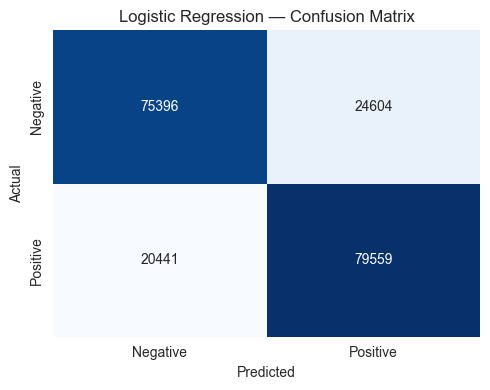

In [13]:
plot_confusion(y_test, y_pred, 'Logistic Regression — Confusion Matrix')


---
## 3. Model interpretation


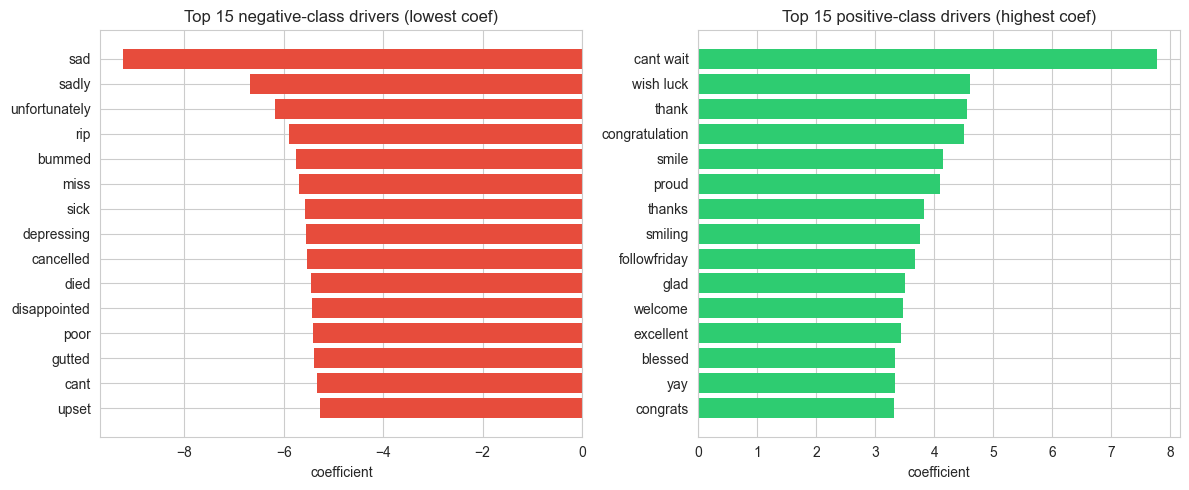

In [14]:
# Logistic Regression — most positive and most negative coefficients
feature_names = np.asarray(tfidf.get_feature_names_out())
coefs = model.coef_.flatten()
top_pos = coefs.argsort()[-15:][::-1]
top_neg = coefs.argsort()[:15]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(list(reversed(feature_names[top_neg])),
             list(reversed(coefs[top_neg])), color=PALETTE[0], edgecolor='none')
axes[0].set_title('Top 15 negative-class drivers (lowest coef)', fontsize=12)
axes[0].set_xlabel('coefficient')
axes[1].barh(list(reversed(feature_names[top_pos])),
             list(reversed(coefs[top_pos])), color=PALETTE[1], edgecolor='none')
axes[1].set_title('Top 15 positive-class drivers (highest coef)', fontsize=12)
axes[1].set_xlabel('coefficient')
plt.tight_layout()
plt.show()


In [15]:
print(f'Logistic Regression headline — '
      f'F1: {metrics["f1"]:.4f}, Accuracy: {metrics["accuracy"]:.4f}')

Logistic Regression headline — F1: 0.7794, Accuracy: 0.7748


---
## 4. Mini-conclusion

This notebook reports the **Logistic Regression** baseline result. Cross-model comparison, the three additional experiments, and the Sentiment140 benchmark verdict are consolidated in `phase3_evaluation.ipynb`.